# World Cup Statistical Irregularities

**Goal.** Pull the full history of the men's FIFA World Cup (1930–2022) — matches, scores,
phases, referees, bookings — plus a FIFA-leadership table, and run statistical models that
surface **irregularities worth looking into**.

**What this is — and isn't.** This is an *exploratory screen*. Every number below is computed
over the same fixed slice of history, so we are making a great many comparisons at once and the
individual scores are inflated by that multiplicity. Nothing here is proof of wrongdoing; the
ranked table is a list of **leads to investigate**, with a Benjamini–Hochberg *q*-value attached
wherever a genuine statistical test exists so the multiple-testing burden is explicit.

**Team strength.** Every downstream question — expected goals, strength-of-schedule, host
over/under-performance — needs a measure of how strong each team was *at the time*. We use an
**Elo** rating built over **every international match since 1872** (friendlies, qualifiers,
continental cups, World Cups) from the `martj42/international_results` dataset. This matters: a
World-Cup-only Elo would enter each debutant at a neutral 1500 regardless of real strength (Qatar
2022, Japan on debut in 1998, …); the full-history version grounds every team in its actual
record from the first whistle. We keep the World-Cup-only Elo too, purely as a self-contained
cross-check.

In [1]:
# --- Environment bootstrap ---------------------------------------------------------
# This notebook imports the `worldcup_anomalies` package. Locally it's installed via uv;
# on Colab (or any fresh kernel) it isn't present, so install it straight from GitHub.
try:
    import worldcup_anomalies  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/jorge-sader/worldcup-anomalies.git",
    ])
    import worldcup_anomalies  # noqa: F401
print("worldcup_anomalies is ready — data is fetched from the web on first use.")

worldcup_anomalies is ready — data is fetched from the web on first use.


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
# Colour-blind-safe categorical palette (Okabe–Ito).
PAL = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
pd.set_option("display.max_colwidth", 90)

from worldcup_anomalies.fetch import load_data
from worldcup_anomalies.elo import compute_elo, pre_tournament_ratings
from worldcup_anomalies.intl_elo import load_intl_results, build_intl_elo, annotate_world_cup

data = load_data()                                  # men's-only, cached under data/raw/
elo_wc = compute_elo(data.matches)                  # self-contained World-Cup-only Elo
elo_timeline = build_intl_elo(load_intl_results())  # full-history Elo, per-team over 1872–2026
elo = annotate_world_cup(data.matches, elo_timeline)  # grounded ratings per WC match (primary)
print("Loaded data and computed both World-Cup-only and full-history Elo ratings.")

Loaded data and computed both World-Cup-only and full-history Elo ratings.


## 1. What's in the data

The match/referee/booking source is the [`jfjelstul/worldcup`](https://github.com/jfjelstul/worldcup)
normalized dataset (filtered to men's editions). Card/booking data only exists from **1970**
onward — a hard limit of the historical record — so the referee-discipline analysis is a
1970–2022 story. Referee *identity* and match results span the full 1930–2022.

In [3]:
display(data.summary().set_index("table"))
n_t = data.tournaments["tournament_id"].nunique()
print(f"{n_t} men's tournaments, {data.tournaments.year.min()}–{data.tournaments.year.max()}")
card_years = pd.to_datetime(data.bookings.match_date).dt.year
print(f"Card data: {card_years.min()}–{card_years.max()}  |  {len(data.referees)} referees")

,rows
table,
tournaments,22
tournament_stages,113
tournament_standings,88
matches,964
goals,2720
penalty_kicks,320
bookings,2624
referees,400
referee_appearances,964


22 men's tournaments, 1930–2022
Card data: 1970–2022  |  400 referees


## 2. General context: tournaments, paths, and how the Elo works

Before the anomaly detectors, three orienting views: a reference table of every World Cup, a
visual comparison of how hard each champion's road to the title was, and a plain-language primer
on the Elo rating that drives everything downstream.

### 2a. Every World Cup at a glance

Hosts, field size, games, penalty shootouts, cards, and the top-four finishers. Card columns are
**0 before 1970** — booking data simply does not exist further back.

In [4]:
from worldcup_anomalies.reports import tournament_overview, team_path, champions_paths

overview = tournament_overview(data)
display(
    overview.style
    .format({"teams": "{:.0f}", "games": "{:.0f}", "penalty_shootouts": "{:.0f}",
             "yellow": "{:.0f}", "red": "{:.0f}"})
    .background_gradient(subset=["games", "yellow", "red"], cmap="Blues")
    .set_caption("Men's FIFA World Cups, 1930–2022")
    .hide(axis="index")
)

year,host,teams,games,penalty_shootouts,yellow,red,fourth,third,runner_up,champion
1930,Uruguay,13,18,0,0,0,Yugoslavia,United States,Argentina,Uruguay
1934,Italy,16,17,0,0,0,Austria,Germany,Czechoslovakia,Italy
1938,France,15,18,0,0,0,Sweden,Brazil,Hungary,Italy
1950,Brazil,13,22,0,0,0,Spain,Sweden,Brazil,Uruguay
1954,Switzerland,16,26,0,0,0,Uruguay,Austria,Hungary,West Germany
1958,Sweden,16,35,0,0,0,West Germany,France,Sweden,Brazil
1962,Chile,16,32,0,0,0,Yugoslavia,Chile,Czechoslovakia,Brazil
1966,England,16,32,0,0,0,Soviet Union,Portugal,West Germany,England
1970,Mexico,16,32,0,52,0,Uruguay,West Germany,Italy,Brazil
1974,West Germany,16,38,0,87,5,Brazil,Poland,Netherlands,West Germany


### 2b. Road to the title — comparing champions' paths

Each row is a champion; each column a game in order. **Colour = the opponent's strength as a
*within-edition percentile*** (100 = one of the strongest teams that tournament) — an era-fair
measure, since raw Elo inflates over the decades. The knockout rounds are boxed: blue = R16,
orange = QF, red = SF/Final. This "path" view makes strength-of-schedule legible in a way a table
of numbers can't — and the same helper drives the interactive team explorer just below.

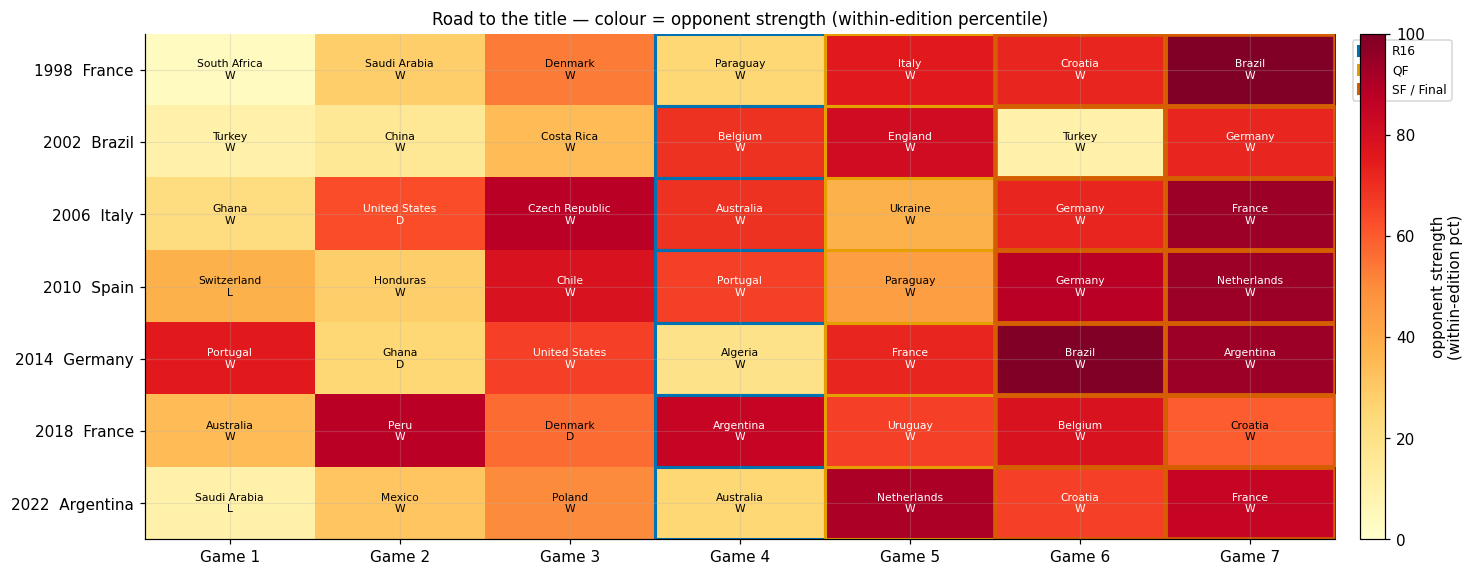

In [5]:
import matplotlib.patches as mpatches

STAGE_EDGE = {"R16": "#0072B2", "QF": "#E69F00", "SF": "#D55E00", "FIN": "#D55E00"}

def plot_paths_grid(entries, title, row_h=0.62):
    # entries: list of (row_label, path_df). Colour = opponent within-edition strength pct.
    maxg = max(len(p) for _, p in entries)
    nrows = len(entries)
    E = np.full((nrows, maxg), np.nan)
    labels = np.empty((nrows, maxg), dtype=object); labels[:] = ""
    stages = np.empty((nrows, maxg), dtype=object); stages[:] = ""
    ylabels = []
    for i, (lab, p) in enumerate(entries):
        ylabels.append(lab)
        for r in p.itertuples():
            E[i, r.game_no - 1] = r.opponent_strength_pct
            labels[i, r.game_no - 1] = f"{r.opponent}\n{r.result[:1].upper()}"
            stages[i, r.game_no - 1] = r.stage_short
    fig, ax = plt.subplots(figsize=(1.5 * maxg + 3, max(2.6, row_h * nrows + 1)))
    im = ax.imshow(E, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
    for i in range(nrows):
        for j in range(maxg):
            if not labels[i, j]:
                continue
            v = E[i, j]
            tc = "white" if (not np.isnan(v) and v > 62) else "black"
            ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=7, color=tc)
            edge = STAGE_EDGE.get(stages[i, j])
            if edge:
                lw = 3 if stages[i, j] in ("SF", "FIN") else 2
                ax.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                                edgecolor=edge, lw=lw))
    ax.set_xticks(range(maxg)); ax.set_xticklabels([f"Game {k+1}" for k in range(maxg)])
    ax.set_yticks(range(nrows)); ax.set_yticklabels(ylabels)
    ax.set_title(title, fontsize=11)
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("opponent strength\n(within-edition pct)")
    legend = [mpatches.Patch(edgecolor=c, facecolor="none", label=s, linewidth=2)
              for s, c in [("R16", "#0072B2"), ("QF", "#E69F00"), ("SF / Final", "#D55E00")]]
    ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    return fig, ax

champ_years = [1998, 2002, 2006, 2010, 2014, 2018, 2022]
champ_entries = []
for yr in champ_years:
    row = data.tournaments[data.tournaments.year == yr]
    tid, champ = row.tournament_id.iloc[0], row.winner.iloc[0]
    champ_entries.append((f"{yr}  {champ}", team_path(data, tid, champ, elo)))
plot_paths_grid(champ_entries,
                "Road to the title — colour = opponent strength (within-edition percentile)")
plt.show()

### 2c. Explore any team's historical path (interactive)

Pick a team from the alphabetical dropdown to see **its** road through *every* World Cup it has
played — one row per edition, same encoding as above (colour = opponent strength percentile,
knockout rounds boxed). This is a team's historical strength-of-schedule at a glance: soft groups
show up as pale left-hand cells, deep runs as long rows ending in red knockout boxes.

Same-nation successor names are folded into **continuous entries**: "Germany" spans its West
Germany years, "Russia" the Soviet Union, "Serbia" folds in Serbia & Montenegro — each row still
labelled with the name used in that era (e.g. `1974 · West Germany`). East Germany, Yugoslavia and
Czechoslovakia are kept as their own separate entries.

*The dropdown needs a live kernel* (open in Colab, or run locally). On the static GitHub/nbviewer
view, the **Germany** default is rendered below as a still image (note the West Germany rows folded
in); open in Colab to switch teams, or just call `show_team_history("Brazil")` in a cell.

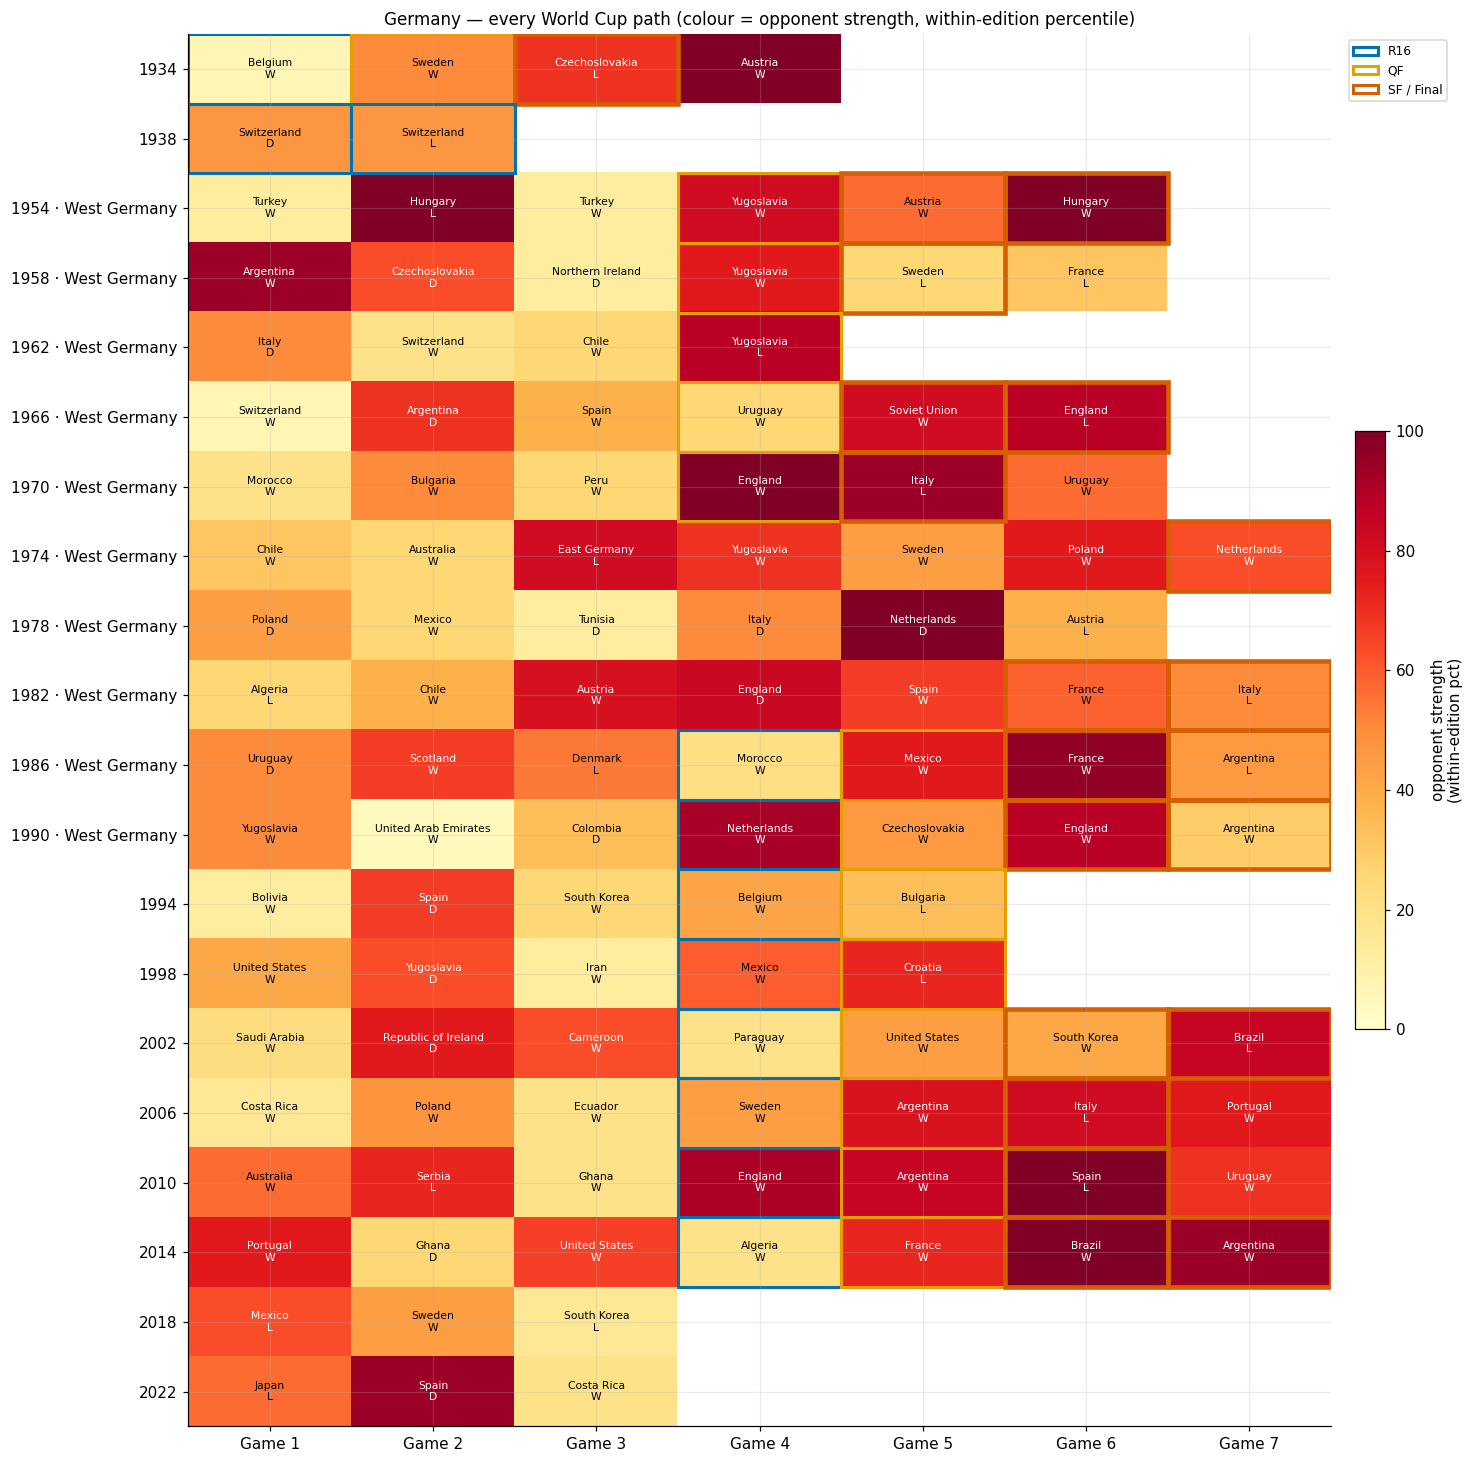

interactive(children=(Dropdown(description='Team:', index=28, options=('Algeria', 'Angola', 'Argentina', 'Aust…

In [6]:
import ipywidgets as widgets
from worldcup_anomalies.reports import all_teams, team_history

def show_team_history(team):
    entries = team_history(data, team, elo)
    if not entries:
        print(f"{team}: no World Cup appearances on record."); return
    plot_paths_grid(
        entries,
        f"{team} — every World Cup path (colour = opponent strength, within-edition percentile)",
    )
    plt.show()

# Static default so the chart is visible even on non-interactive viewers (GitHub/nbviewer):
show_team_history("Germany")

# Live dropdown (needs a running kernel — Colab or local Jupyter):
widgets.interact(
    show_team_history,
    team=widgets.Dropdown(options=all_teams(data), value="Germany", description="Team:"),
);

### 2d. How the Elo is calculated — a worked example

The rating is simple arithmetic applied after every match:

1. **Expected result** from the rating gap: `E = 1 / (1 + 10^((opp − you)/400))` — level ratings
   give `E = 0.5`; a 400-point edge gives ≈ 0.91.
2. **Actual result**: win = 1, draw = 0.5, loss = 0.
3. **Margin multiplier** `G`: 1 for a 1-goal win, 1.5 for 2, `(11+margin)/8` for 3+.
4. **Update**: `Δ = K · G · (actual − expected)` with `K = 40`; you gain Δ, the opponent loses it.

Below, three real matches worked end to end (World-Cup-only Elo, so numbers sit near the 1500
baseline and are easy to follow). Note how an upset moves ratings far more than an expected result.

In [7]:
from worldcup_anomalies.elo import _gd_multiplier, K_FACTOR

def work_match(match_name, year):
    tid = data.tournaments[data.tournaments.year == year].tournament_id.iloc[0]
    sel = elo_wc[(elo_wc.tournament_id == tid) & (elo_wc.match_name == match_name)]
    assert len(sel) == 1, f"match not found: {match_name} ({year})"
    r = sel.iloc[0]
    exp_h = r.elo_prob_home
    actual_h = 1.0 if r.home_team_score > r.away_team_score else (
        0.0 if r.home_team_score < r.away_team_score else 0.5)
    mult = _gd_multiplier(r.home_team_score - r.away_team_score)
    delta = K_FACTOR * mult * (actual_h - exp_h)
    return {
        "match": f"{match_name} ({year})",
        "score": f"{int(r.home_team_score)}–{int(r.away_team_score)}",
        "home_pre": round(r.elo_home_pre), "away_pre": round(r.elo_away_pre),
        "P(home)": round(exp_h, 2), "actual": actual_h, "G(margin)": mult,
        "Δ_home": round(delta, 1),
        "home_post": round(r.elo_home_pre + delta), "away_post": round(r.elo_away_pre - delta),
    }

worked = pd.DataFrame([
    work_match("Argentina vs Saudi Arabia", 2022),   # huge upset (favourite lost)
    work_match("Argentina vs Croatia", 2022),        # strong favourite delivers
    work_match("Brazil vs Germany", 2014),           # 1–7: margin multiplier bites
])
display(worked.set_index("match"))
print("Argentina (heavy favourite) LOST to Saudi Arabia → a big negative Δ_home, with the "
      "same points gained by low-rated Saudi Arabia. Argentina beating Croatia as favourites "
      "→ small Δ. Germany's 7–1 → the margin multiplier amplifies an already-expected win.")

,score,home_pre,away_pre,P(home),actual,G(margin),Δ_home,home_post,away_post
match,,,,,,,,,
Argentina vs Saudi Arabia (2022),1–2,1655,1348,0.85,0.0,1.000,-34.2,1621,1382
Argentina vs Croatia (2022),3–0,1679,1624,0.58,1.0,1.750,29.5,1709,1595
Brazil vs Germany (2014),1–7,1809,1776,0.64,0.0,2.125,-54.2,1755,1830


Argentina (heavy favourite) LOST to Saudi Arabia → a big negative Δ_home, with the same points gained by low-rated Saudi Arabia. Argentina beating Croatia as favourites → small Δ. Germany's 7–1 → the margin multiplier amplifies an already-expected win.


### 2e. Ratings over time

The full-history engine tracks every national team from 1872. Here are a few traditional powers —
you can see eras rise and fade (Hungary's 1950s peak, Brazil's long dominance, Spain's late-2000s
surge), which is exactly the signal the strength-of-schedule and upset detectors lean on.

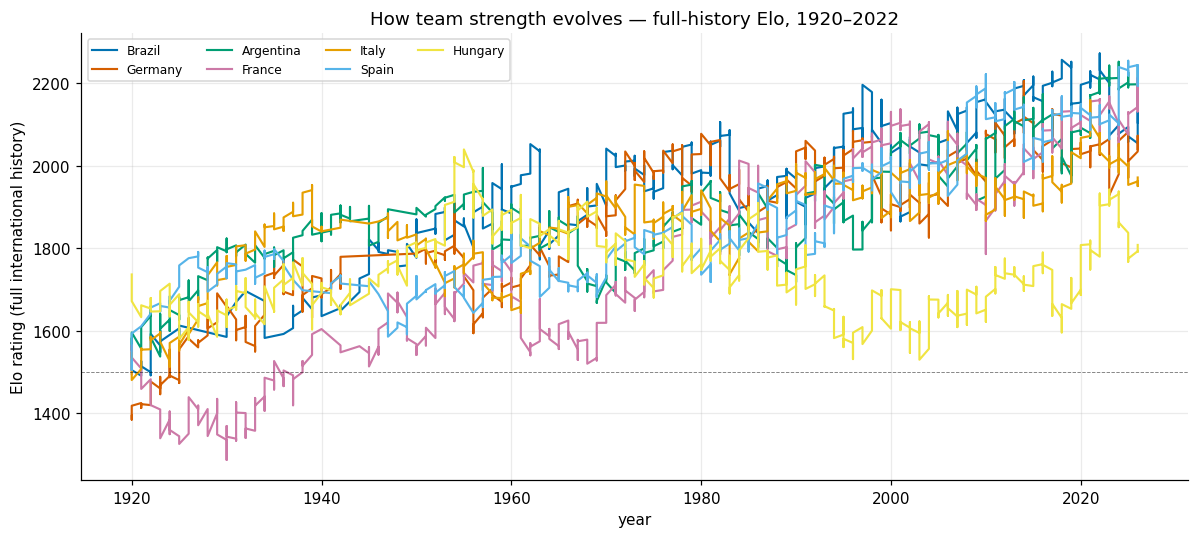

In [8]:
traj_teams = ["Brazil", "Germany", "Argentina", "France", "Italy", "Spain", "Hungary"]
fig, ax = plt.subplots(figsize=(11, 5))
for i, tm in enumerate(traj_teams):
    if tm not in elo_timeline:
        continue
    dates, ratings = elo_timeline[tm]
    yrs = pd.to_datetime(dates).year
    keep = yrs >= 1920
    ax.plot(yrs[keep], np.array(ratings)[keep], label=tm, color=PAL[i % len(PAL)], lw=1.4)
ax.axhline(1500, color="k", lw=0.6, ls="--", alpha=0.5)
ax.set_xlabel("year"); ax.set_ylabel("Elo rating (full international history)")
ax.set_title("How team strength evolves — full-history Elo, 1920–2022")
ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

## 3. Team strength: World-Cup-only vs full international history

Why this matters for the whole analysis. A World-Cup-only Elo has a **cold-start** problem: it has
never seen a team until its World Cup debut, so it enters that team at a neutral **1500** — even
if the team is, by any real measure, weak or strong. The full-history Elo has already watched the
team play dozens of qualifiers and friendlies, so it enters with a *grounded* rating.

The clearest illustration is the ratings **entering the 2022 World Cup**: under the full-history
model nobody sits at a blank 1500 (Qatar enters around 1790, earned over years of Asian
qualifiers), and the spread between strong and weak teams is far more realistic.

In [9]:
pw = (pre_tournament_ratings(elo_wc).query("tournament_id == 'WC-2022'")
      [["team_name", "elo_pre"]].rename(columns={"elo_pre": "wc_only"}))
pf = (pre_tournament_ratings(elo).query("tournament_id == 'WC-2022'")
      [["team_name", "elo_pre"]].rename(columns={"elo_pre": "full_history"}))
cmp = pw.merge(pf, on="team_name")
cmp["debutant_pinned_at_1500"] = cmp["wc_only"].round(0) == 1500
display(cmp.sort_values("full_history", ascending=False).round(0)
        .reset_index(drop=True))
print("Under the World-Cup-only Elo, Qatar (a WC debutant) is pinned at 1500; "
      "the full-history Elo enters them near 1790 from their real record.")

,team_name,wc_only,full_history,debutant_pinned_at_1500
0,Brazil,1720.0,2256.0,False
1,Argentina,1655.0,2212.0,False
2,Spain,1639.0,2132.0,False
3,Netherlands,1805.0,2124.0,False
4,Portugal,1581.0,2083.0,False
5,France,1756.0,2054.0,False
6,Germany,1764.0,2054.0,False
7,Belgium,1664.0,2053.0,False
8,Denmark,1561.0,2046.0,False
9,Uruguay,1574.0,2020.0,False


Under the World-Cup-only Elo, Qatar (a WC debutant) is pinned at 1500; the full-history Elo enters them near 1790 from their real record.


The rest of the notebook uses the **full-history** ratings (`elo`). Everything is written to work
with either — swap in `elo_wc` to reproduce the self-contained version.

## 4. The headline: irregularities worth looking into

`collect_anomalies` runs all five detectors and maps each onto a single, clipped `anomaly_score`
(a z-magnitude) so they can be ranked together. `q_value` is the Benjamini–Hochberg FDR value,
populated only where a real test exists (referee card rates, host card bias).

In [10]:
from worldcup_anomalies.anomalies import collect_anomalies

ranked = collect_anomalies(data, elo)
print(f"{len(ranked)} flagged items across {ranked.category.nunique()} detectors\n")
display(ranked.head(25).set_index("rank")[
    ["category", "subject", "detail", "anomaly_score", "q_value"]
])

88 flagged items across 8 detectors



,category,subject,detail,anomaly_score,q_value
rank,,,,,
1,upset,Cameroon vs Brazil,"1-0 in group stage; favourite (Elo gap 557) lost, expected ~0.5-3.8",5.000000,NaN
2,upset,Argentina vs Saudi Arabia,"1-2 in group stage; favourite (Elo gap 457) lost, expected ~3.1-0.5",4.680750,NaN
3,upset,Spain vs Switzerland,"0-1 in group stage; favourite (Elo gap 432) lost, expected ~3.0-0.6",4.359666,NaN
4,referee-cards,Ľuboš Micheľ (Slovakia),"5 matches, 39 cards vs 20 expected (7.8/match)",4.273159,0.000694
5,referee-cards,Arturo Brizio Carter (Mexico),"6 matches, 37 cards vs 22 expected (6.2/match)",3.311262,0.016718
6,upset,West Germany vs Algeria,"1-2 in group stage; favourite (Elo gap 338) lost, expected ~2.5-0.7",3.173174,NaN
7,upset,South Korea vs Germany,"2-0 in group stage; favourite (Elo gap 325) lost, expected ~0.7-2.4",3.002769,NaN
8,convenient-result,West Germany vs Austria,"1-0, both advanced; eliminated Algeria, Chile who finished earlier; non-simultaneous f...",3.000000,NaN
9,convenient-result,Spain vs Northern Ireland,"0-1, both advanced; eliminated Honduras, Yugoslavia who finished earlier; non-simultan...",3.000000,NaN


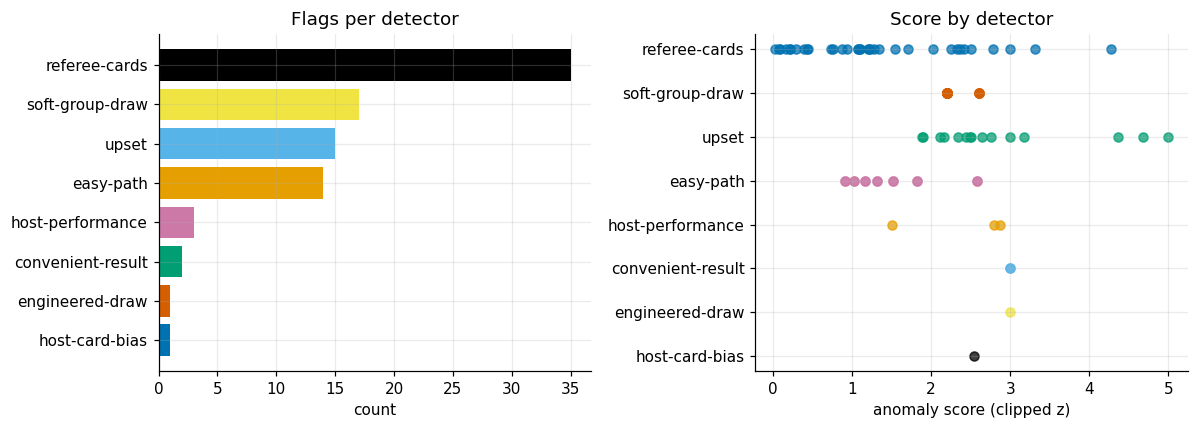

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
cat_order = ranked.category.value_counts()
ax1.barh(cat_order.index[::-1], cat_order.values[::-1],
         color=[PAL[i % len(PAL)] for i in range(len(cat_order))])
ax1.set_title("Flags per detector"); ax1.set_xlabel("count")

for i, cat in enumerate(cat_order.index):
    sub = ranked[ranked.category == cat]
    ax2.scatter(sub.anomaly_score, [i] * len(sub), color=PAL[i % len(PAL)], alpha=0.75, s=35)
ax2.set_yticks(range(len(cat_order))); ax2.set_yticklabels(cat_order.index)
ax2.set_xlabel("anomaly score (clipped z)"); ax2.set_title("Score by detector")
ax2.invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Detector — Upsets (results that defied strength)

A favourite thrashing a minnow is *statistically* surprising but not interesting. What's worth a
look is the reverse: a clearly weaker side (by pre-match Elo) **winning**. We rank those by the
Elo gap the result defied. With grounded ratings this rediscovers the canonical shocks — Cameroon
over Brazil (1990), Argentina losing to Saudi Arabia (2022), Switzerland over Spain (2010),
Algeria over West Germany (1982), South Korea over Germany (2018).

,year,match_name,stage_name,home_team_score,away_team_score,elo_gap_defied
0,2022,Cameroon vs Brazil,group stage,1,0,556.540428
1,2022,Argentina vs Saudi Arabia,group stage,1,2,457.241429
2,2010,Spain vs Switzerland,group stage,0,1,431.908490
3,1982,West Germany vs Algeria,group stage,1,2,338.296387
4,2018,South Korea vs Germany,group stage,2,0,324.851762
5,1998,Spain vs Nigeria,group stage,2,3,305.296139
6,2006,Czech Republic vs Ghana,group stage,0,2,296.548029
7,1982,Italy vs Brazil,second group stage,3,2,285.754633
8,1986,Portugal vs England,group stage,1,0,284.867654
9,2002,France vs Senegal,group stage,0,1,280.697086


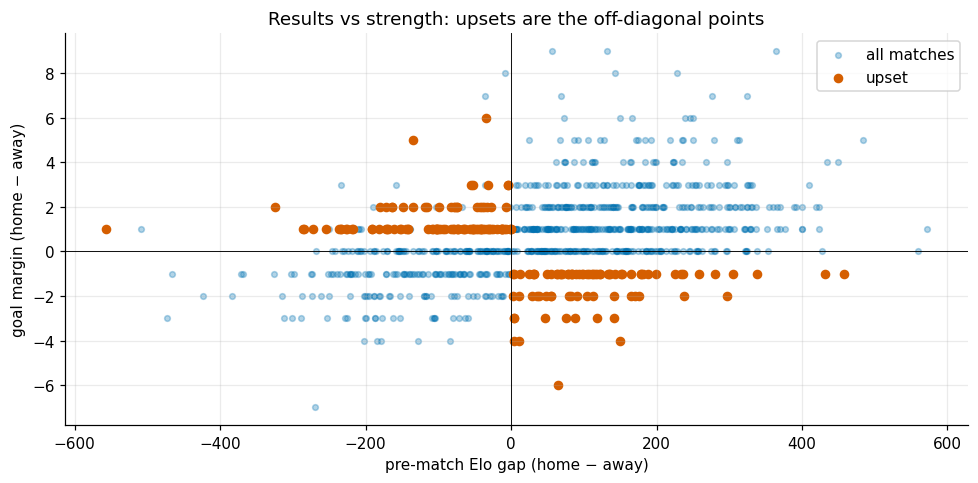

In [12]:
from worldcup_anomalies.models import score_surprise

ss = score_surprise(elo, data.team_appearances)
upsets = ss[(ss.upset) & (ss.year >= 1958)].sort_values("elo_gap_defied", ascending=False)
display(upsets.head(12)[[
    "year", "match_name", "stage_name", "home_team_score", "away_team_score", "elo_gap_defied"
]].reset_index(drop=True))

fig, ax = plt.subplots()
ax.scatter(ss.elo_home_pre - ss.elo_away_pre, ss.home_team_score - ss.away_team_score,
           s=14, alpha=0.3, color=PAL[0], label="all matches")
ax.scatter(upsets.elo_home_pre - upsets.elo_away_pre,
           upsets.home_team_score - upsets.away_team_score,
           s=28, color=PAL[1], label="upset")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("pre-match Elo gap (home − away)"); ax.set_ylabel("goal margin (home − away)")
ax.set_title("Results vs strength: upsets are the off-diagonal points")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Detector — "Convenient" group results

The archetype is the 1982 **Disgrace of Gijón**: West Germany beat Austria 1-0, a result that
sent *both* through at Algeria's expense, in a match played the day *after* Algeria had finished.
FIFA's response was to make final group matches kick off simultaneously from 1986 on.

The detector flags the last-played first-round group match whose result advanced **both** teams,
where a non-advancing team had already finished on an earlier day (an informational advantage).
Tellingly it flags **only 1982** — the structure that made this possible was legislated away in
1986, and the detector independently rediscovers that.

In [13]:
from worldcup_anomalies.models import detect_convenient_results

conv = detect_convenient_results(data.matches, data.group_standings)
display(conv[[
    "tournament_id", "match_name", "match_date", "score",
    "non_simultaneous", "eliminated_finished_earlier", "suspicion"
]])
print("These are the last two World Cups (both 1982) before simultaneous final "
      "group kickoffs were mandated in 1986.")

,tournament_id,match_name,match_date,score,non_simultaneous,eliminated_finished_earlier,suspicion
0,WC-1982,West Germany vs Austria,1982-06-25,1-0,True,"Algeria, Chile",1.5
1,WC-1982,Spain vs Northern Ireland,1982-06-25,0-1,True,"Honduras, Yugoslavia",1.5


These are the last two World Cups (both 1982) before simultaneous final group kickoffs were mandated in 1986.


## 7. Detector — Referee discipline

**(a)** Do individual referees hand out far more (or fewer) cards than the match context warrants?
We model expected cards from era, knockout-vs-group, and how competitive the match is (by Elo),
then score each referee's standardized residual. **(b)** Do **hosts** get an easier ride — fewer
cards than their opponents in the matches they play?

,referee_name,referee_country,n_matches,obs_cards,exp_cards,cards_per_match,z
0,Ľuboš Micheľ,Slovakia,5,39,19.925485,7.800000,4.273159
1,Arturo Brizio Carter,Mexico,6,37,21.607848,6.166667,3.311262
2,Howard Webb,England,6,39,24.261818,6.500000,2.992142
3,César Arturo Ramos,Mexico,7,15,30.328155,2.142857,-2.783344
4,Néstor Pitana,Argentina,9,23,38.539120,2.555556,-2.503085
5,Björn Kuipers,Netherlands,7,16,29.010715,2.285714,-2.415583
6,Joël Quiniou,France,7,37,25.151816,5.285714,2.362475
7,Antonio Mateu Lahoz,Spain,5,32,21.277745,6.400000,2.324467
8,Jamal Al-Sharif,Syria,6,32,21.539870,5.333333,2.253801
9,Horacio Elizondo,Argentina,5,29,19.959566,5.800000,2.023549


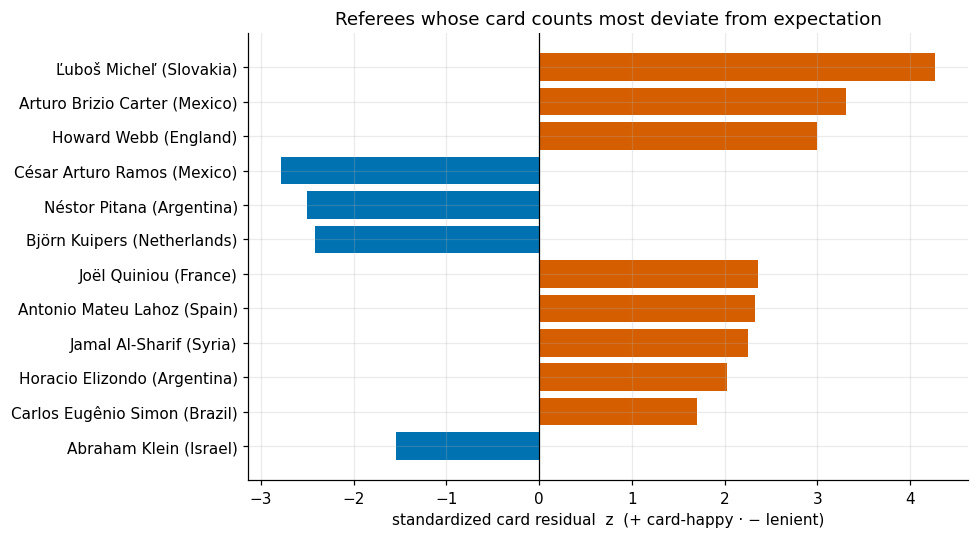

In [14]:
from worldcup_anomalies.referees import referee_outliers, host_card_bias

ro = referee_outliers(data.matches, data.referee_appearances, data.bookings, elo, min_matches=5)
top = ro.reindex(ro.z.abs().sort_values(ascending=False).index).head(12)
display(top[["referee_name", "referee_country", "n_matches",
             "obs_cards", "exp_cards", "cards_per_match", "z"]].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 5))
t = top.iloc[::-1]
colors = [PAL[1] if z > 0 else PAL[0] for z in t.z]
ax.barh(t.referee_name + " (" + t.referee_country + ")", t.z, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("standardized card residual  z  (+ card-happy · − lenient)")
ax.set_title("Referees whose card counts most deviate from expectation")
plt.tight_layout(); plt.show()

In [15]:
per_t, host_bias = host_card_bias(data.matches, data.bookings)
print("HOST CARD BIAS (matches involving the host nation, 1970+):")
for k, v in host_bias.items():
    print(f"  {k}: {v}")
print(f"\nIn decisive matches the host received FEWER cards than its opponent "
      f"{host_bias['share_host_fewer']:.0%} of the time "
      f"(sign-test p = {host_bias['sign_test_p']:.3f}). Suggestive of a home-crowd/officiating "
      f"tilt — though hosts are also often the stronger, less-pressed side.")

HOST CARD BIAS (matches involving the host nation, 1970+):
  n_decisive_matches: 51
  host_fewer_cards: 35
  host_more_cards: 16
  share_host_fewer: 0.6862745098039216
  sign_test_p: 0.010973562899720513
  total_host_cards: 116
  total_opp_cards: 158

In decisive matches the host received FEWER cards than its opponent 69% of the time (sign-test p = 0.011). Suggestive of a home-crowd/officiating tilt — though hosts are also often the stronger, less-pressed side.


## 8. Detector — "Easy path" / seeding luck

For every team that reached the quarter-final or deeper, we measure the strength of the teams it
actually had to beat — the mean pre-tournament Elo of its opponents — and how many established
"powers" (top-quartile that edition) it faced. A run to the semi-final or final past unusually
weak opposition is a soft draw, *whether or not* the team was the host. We compare within the
round reached (finalists vs finalists) so that deeper runs facing more games aren't penalised.

In [16]:
from worldcup_anomalies.paths import easy_path_scores

ep = easy_path_scores(elo, data.team_appearances)
finals = ep[ep.round_label == "Final"].sort_values("mean_opp_elo").head(6)
semis = ep[ep.round_label == "SF"].sort_values("mean_opp_elo").head(6)
print("Easiest routes to the FINAL:")
display(finals[["year", "team_name", "mean_opp_elo", "max_opp_elo",
                "n_powers_faced", "easiness_pct"]].reset_index(drop=True))
print("Easiest routes to the SEMI-FINAL:")
display(semis[["year", "team_name", "mean_opp_elo", "max_opp_elo",
               "n_powers_faced", "easiness_pct"]].reset_index(drop=True))

Easiest routes to the FINAL:


,year,team_name,mean_opp_elo,max_opp_elo,n_powers_faced,easiness_pct
0,1958,Brazil,1712.128004,1847.362790,1,100.000000
1,1966,England,1745.642414,1842.968959,0,97.058824
2,1958,Sweden,1750.780194,1885.474283,2,94.117647
3,1966,West Germany,1757.631507,1902.627367,2,91.176471
4,1970,Italy,1758.439986,1916.932555,1,88.235294
5,1962,Brazil,1776.240584,1825.971353,2,85.294118


Easiest routes to the SEMI-FINAL:


,year,team_name,mean_opp_elo,max_opp_elo,n_powers_faced,easiness_pct
0,1958,France,1710.914402,1862.199502,1,100.000000
1,1962,Yugoslavia,1716.436960,1921.862954,2,97.058824
2,1958,West Germany,1722.681569,1882.586590,1,94.117647
3,1970,West Germany,1762.189777,1939.039327,2,91.176471
4,1966,Soviet Union,1791.275860,1913.498840,1,88.235294
5,1978,Brazil,1799.869304,1894.800424,0,85.294118


### A worked check: did Argentina have easy paths?

A natural suspicion is that a serial deep-runner reached finals via soft draws. The data says the
opposite — Argentina's finalist runs sit at the **hard** end of the distribution, because from the
quarter-finals on they repeatedly met elite teams (2022: Netherlands, Croatia, France; 2014:
Netherlands, Germany). `easiness_pct` is the percentile of *weakness* within the round reached, so
**low = hard path**.

In [17]:
arg = ep[ep.team_name == "Argentina"].copy()
n_final = (ep.round_label == "Final").sum()
n_sf = (ep.round_label == "SF").sum()
display(arg[["year", "round_label", "n_opponents", "mean_opp_elo",
             "max_opp_elo", "n_powers_faced", "easiness_pct"]]
        .sort_values("year").reset_index(drop=True))
argf = arg[arg.round_label == "Final"].sort_values("easiness_pct")
for _, r in argf.iterrows():
    harder_than = 100 - r.easiness_pct
    print(f"{int(r.year)} Argentina (Final): path was harder than {harder_than:.0f}% "
          f"of all {n_final} finalist runs — faced {int(r.n_powers_faced)} top-quartile teams "
          f"(toughest Elo {r.max_opp_elo:.0f}).")
print("\nConclusion: Argentina is a counter-example to an easy path, not an instance of one.")

,year,round_label,n_opponents,mean_opp_elo,max_opp_elo,n_powers_faced,easiness_pct
0,1966,QF,4,1748.608984,1902.627367,1,93.055556
1,1974,QF,6,1841.793653,1974.840158,3,44.444444
2,1978,Final,7,1877.764183,2034.371335,3,38.235294
3,1982,QF,5,1813.886533,2055.452845,1,63.888889
4,1986,Final,7,1818.421845,1982.878216,2,70.588235
5,1990,Final,7,1870.142599,1959.495129,3,44.117647
6,1998,QF,5,1860.816125,1973.722398,2,31.944444
7,2006,QF,5,1908.633368,2013.248428,1,12.500000
8,2010,QF,5,1873.855164,1982.912083,2,29.166667
9,2014,Final,7,1913.233048,2083.085395,2,17.647059


2022 Argentina (Final): path was harder than 88% of all 34 finalist runs — faced 2 top-quartile teams (toughest Elo 2124).
2014 Argentina (Final): path was harder than 82% of all 34 finalist runs — faced 2 top-quartile teams (toughest Elo 2083).
1978 Argentina (Final): path was harder than 62% of all 34 finalist runs — faced 3 top-quartile teams (toughest Elo 2034).
1990 Argentina (Final): path was harder than 56% of all 34 finalist runs — faced 3 top-quartile teams (toughest Elo 1959).
1986 Argentina (Final): path was harder than 29% of all 34 finalist runs — faced 2 top-quartile teams (toughest Elo 1983).

Conclusion: Argentina is a counter-example to an easy path, not an instance of one.


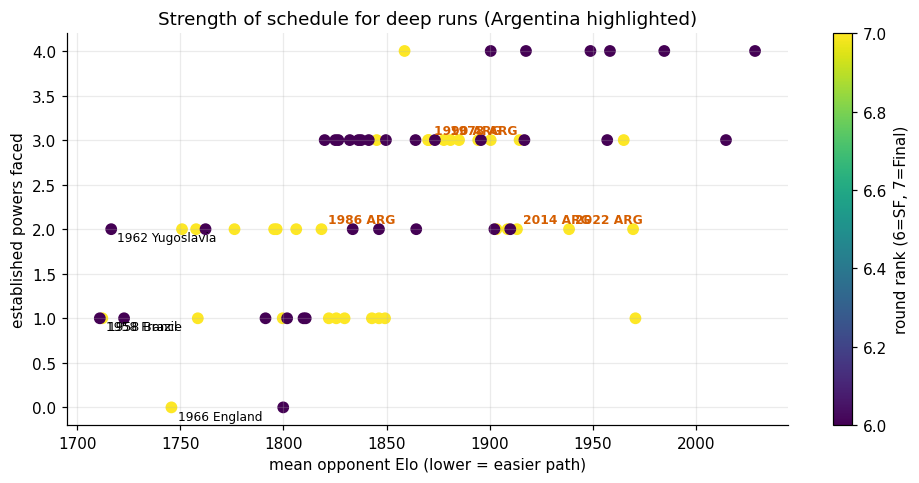

In [18]:
deep = ep[ep.round_rank >= 6].copy()
fig, ax = plt.subplots()
sc = ax.scatter(deep.mean_opp_elo, deep.n_powers_faced, c=deep.round_rank, cmap="viridis", s=45)
for _, r in deep[deep.team_name == "Argentina"].iterrows():
    ax.annotate(f"{int(r.year)} ARG", (r.mean_opp_elo, r.n_powers_faced), fontsize=8,
                color=PAL[1], fontweight="bold", xytext=(4, 4), textcoords="offset points")
for _, r in pd.concat([finals.head(2), semis.head(2)]).iterrows():
    ax.annotate(f"{int(r.year)} {r.team_name}", (r.mean_opp_elo, r.n_powers_faced),
                fontsize=8, xytext=(4, -8), textcoords="offset points")
ax.set_xlabel("mean opponent Elo (lower = easier path)")
ax.set_ylabel("established powers faced")
ax.set_title("Strength of schedule for deep runs (Argentina highlighted)")
plt.colorbar(sc, label="round rank (6=SF, 7=Final)")
plt.tight_layout(); plt.show()

### The group / knockout split

A whole-path average hides the *shape* of a run. Splitting strength-of-schedule into the group
phase vs the knockout phase makes the "coast then earn it" profile explicit: `group_softness_pct`
(100 = softest group that year) against `ko_toughness_pct` (100 = toughest knockout opponents),
with `split_index` high when both hold. The knockout mean includes the round of 16, so a run
that's only brutal in the final match or two scores moderately.

In [19]:
from worldcup_anomalies.paths import phase_strength_split

split = phase_strength_split(elo, data.team_appearances)
deep_split = split[split["rank"] >= 6]
print("Purest 'soft group, brutal knockout' profiles among SF/Final teams:")
display(deep_split.sort_values("split_index", ascending=False).head(8)[
    ["year", "team_name", "round_label", "group_softness_pct",
     "ko_toughness_pct", "split_index"]
].round(0).reset_index(drop=True))

print("Argentina — group vs knockout, each knockout appearance:")
display(split[split.team_name == "Argentina"].sort_values("year")[
    ["year", "round_label", "group_opp_elo", "ko_max_opp_elo",
     "group_softness_pct", "ko_toughness_pct", "split_index"]
].round(0).reset_index(drop=True))
print("Argentina's 2014 & 2022 groups were among the softest (softness ~88), but knockout "
      "toughness was only moderate — the R16 (Switzerland, Australia) was beatable and the "
      "brutality was concentrated in the last one or two games. A soft group, not a brutal path.")

Purest 'soft group, brutal knockout' profiles among SF/Final teams:


,year,team_name,round_label,group_softness_pct,ko_toughness_pct,split_index
0,2006,France,Final,88.0,88.0,88.0
1,1982,France,SF,75.0,88.0,81.0
2,2010,Netherlands,Final,88.0,69.0,78.0
3,2014,Brazil,SF,81.0,75.0,78.0
4,1990,West Germany,Final,94.0,62.0,78.0
5,1958,Sweden,Final,62.0,88.0,75.0
6,1958,France,SF,75.0,75.0,75.0
7,2002,Brazil,Final,88.0,50.0,69.0


Argentina — group vs knockout, each knockout appearance:


,year,round_label,group_opp_elo,ko_max_opp_elo,group_softness_pct,ko_toughness_pct,split_index
0,1930,Final,1390.0,1687.0,75.0,25.0,50.0
1,1966,QF,1697.0,1903.0,62.0,100.0,81.0
2,1978,Final,1852.0,2034.0,25.0,100.0,62.0
3,1986,Final,1766.0,1983.0,69.0,56.0,62.0
4,1990,Final,1805.0,1959.0,50.0,81.0,66.0
5,1994,R16,1729.0,1852.0,94.0,31.0,62.0
6,1998,QF,1788.0,1974.0,62.0,62.0,62.0
7,2006,QF,1901.0,1948.0,12.0,25.0,19.0
8,2010,QF,1808.0,1983.0,62.0,50.0,56.0
9,2014,Final,1821.0,2083.0,88.0,31.0,59.0


Argentina's 2014 & 2022 groups were among the softest (softness ~88), but knockout toughness was only moderate — the R16 (Switzerland, Australia) was beatable and the brutality was concentrated in the last one or two games. A soft group, not a brutal path.


## 9. Detector — Draw luck: the group is the lever

The `easy_path` metric above averages over the *whole* run — but by the quarter-final it's nearly
impossible to avoid strong teams, so that average drowns out the part that actually matters. If you
wanted to *ease* a team's route, the lever is the **group draw**: hand it a soft group, let the
other powers cluster elsewhere and knock each other out, and it reaches the semis having beaten
nobody. So we isolate the **group stage** and measure it two ways that avoid the traps:

- **Within-edition** — Elo inflates over time, so we compare a team's group only to the *other
  groups that same year* (100 = softest group of the tournament).
- **Seed-controlled** — the top teams are seeded into separate groups *by design*, so "strong team
  + soft group" is the norm. We therefore also rank each seed's group against the *other seeds*
  (`seed_soft_rank` = 1 means the softest group among that year's ~8 seeds).

In [20]:
from worldcup_anomalies.paths import group_draw_difficulty

gd = group_draw_difficulty(elo, data.team_appearances)

# Deep runs (SF/Final) reached from the softest groups, among seeds, within their edition.
soft_deep = gd[(gd["rank"] >= 6) & (gd["is_seed"])].sort_values("seed_soft_rank")
print("Teams that reached the SF/Final from the softest seeded group of their edition:")
display(soft_deep[soft_deep.seed_soft_rank <= 2][
    ["year", "team_name", "round_label", "grp_mean_opp_elo",
     "n_seeds_in_group", "seed_soft_rank", "n_seeds_total"]
].round(0).reset_index(drop=True))

print("Argentina, every appearance — group softness (100=softest that year) and rank among seeds:")
display(gd[gd.team_name == "Argentina"][
    ["year", "round_label", "grp_softness_pct", "seed_soft_rank", "n_seeds_total"]
].round(0).reset_index(drop=True))

Teams that reached the SF/Final from the softest seeded group of their edition:


,year,team_name,round_label,grp_mean_opp_elo,n_seeds_in_group,seed_soft_rank,n_seeds_total
0,1930,Argentina,Final,1390.0,1,1.0,8
1,1966,England,Final,1682.0,0,1.0,8
2,2014,Argentina,Final,1821.0,0,1.0,8
3,1990,West Germany,Final,1712.0,0,1.0,8
4,1978,Netherlands,Final,1771.0,1,2.0,8
5,1974,Netherlands,Final,1748.0,0,2.0,8
6,1962,Yugoslavia,SF,1683.0,1,2.0,8
7,1950,Spain,SF,1598.0,1,2.0,8
8,2006,France,Final,1756.0,0,2.0,8
9,2014,Brazil,SF,1849.0,0,2.0,8


Argentina, every appearance — group softness (100=softest that year) and rank among seeds:


,year,round_label,grp_softness_pct,seed_soft_rank,n_seeds_total
0,1930,Final,92.0,1.0,8
1,1958,group,81.0,3.0,8
2,1962,group,44.0,4.0,8
3,1966,QF,81.0,3.0,8
4,1974,QF,50.0,NaN,8
5,1978,Final,31.0,7.0,8
6,1982,QF,88.0,2.0,8
7,1986,Final,79.0,NaN,8
8,1990,Final,54.0,NaN,8
9,1994,R16,96.0,1.0,8


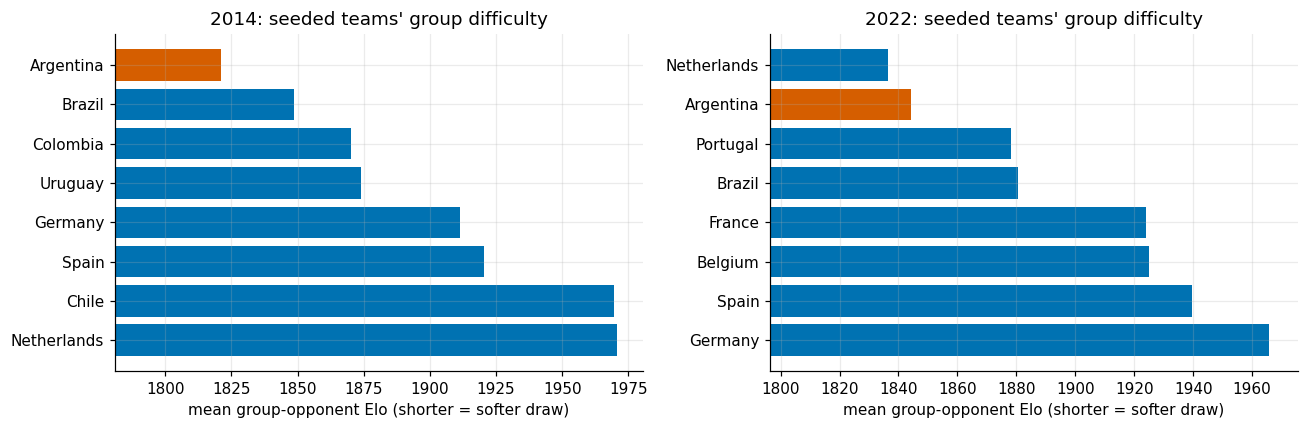

Argentina drew the SOFTEST seeded group in 2014 and the 2nd-softest in 2022 — reaching the Final both times.


In [21]:
# 2014 & 2022: Argentina's group vs the other seeds' groups that year.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, yr in zip(axes, [2014, 2022]):
    s = gd[(gd.year == yr) & (gd.is_seed)].sort_values("grp_mean_opp_elo")
    colors = [PAL[1] if t == "Argentina" else PAL[0] for t in s.team_name]
    ax.barh(s.team_name[::-1], s.grp_mean_opp_elo[::-1], color=colors[::-1])
    ax.set_title(f"{yr}: seeded teams' group difficulty")
    ax.set_xlabel("mean group-opponent Elo (shorter = softer draw)")
    ax.set_xlim(s.grp_mean_opp_elo.min() - 40, s.grp_mean_opp_elo.max() + 10)
plt.tight_layout(); plt.show()
print("Argentina drew the SOFTEST seeded group in 2014 and the 2nd-softest in 2022 — "
      "reaching the Final both times.")

**How to read this honestly.** Argentina's two most recent Final runs *did* start from the softest
(2014) and 2nd-softest (2022) seeded groups of their editions — a real pattern the whole-path metric
missed, and a fair basis for curiosity. But three caveats keep it a *lead, not a verdict*:

1. **It's structural.** Soft-seeded-group-then-deep-run recurs throughout history (1990 West
   Germany, 1998/2006 France, 2002 Brazil, 2010 Netherlands …) — winning is simply easier from a
   soft group, and the best teams are seeded. Argentina is not unique.
2. **Someone is always softest.** By construction one seed draws the softest group every edition;
   observing it after the fact isn't evidence by itself.
3. **No career pattern.** Across all of Argentina's tournaments the draw is mixed — the *hardest*
   seeded group in 2006, 6th of 8 in 2002. The soft draws cluster in 2014 and 2022, i.e. n ≈ 2.

That's exactly what a screen should do: surface the pattern, size it, and refuse to overclaim.

## 10. Lucky or engineered? A fair-draw Monte-Carlo

The group-softness metric shows a team *got* a soft group, but not whether that's surprising —
or whether the other powers were **packed together elsewhere** so they eliminated each other and
cleared the favoured team's path. That packing is the real signature of an engineered draw, and
we test it by simulating thousands of fair draws.

The one thing we can assert without external pot data is that seeding **separates each group's
strongest team** by design. So we hold each group's strongest team fixed and randomly
redistribute everyone else, 10,000 times:

- **`draw_luck_pct`** (per team) — where its group's opponent strength falls vs fair redraws.
  *Low = softer than almost any fair draw.*
- **`rival_clustering_pct`** (per edition) — where the *variance of group strength* falls.
  *High = strong teams bunched into some groups and absent from others (rivals clustered).*

The engineered pattern is the **conjunction**: deep run **+** soft group **+** clustered rivals.
This null ignores pot 2–4 constraints, so it's deliberately *conservative* (under- not
over-states how extreme a draw was).

In [22]:
from worldcup_anomalies.draw import draw_monte_carlo, engineered_draw_flags

draws = draw_monte_carlo(elo, data.group_standings, data.team_appearances, n_sims=10000)

print("Argentina's draw each edition (draw_luck low = soft group; clustering high = rivals packed):")
display(draws[draws.team_name == "Argentina"][
    ["year", "group_name", "round_label", "draw_luck_pct", "rival_clustering_pct"]
].round(0).reset_index(drop=True))

print("Deep-run teams (SF/Final) with the softest groups vs fair draws:")
display(draws[draws.round_rank >= 6].sort_values("draw_luck_pct").head(8)[
    ["year", "team_name", "round_label", "draw_luck_pct", "rival_clustering_pct"]
].round(0).reset_index(drop=True))

Argentina's draw each edition (draw_luck low = soft group; clustering high = rivals packed):


,year,group_name,round_label,draw_luck_pct,rival_clustering_pct
0,1958,Group 1,group,36.0,87.0
1,1982,Group 3,QF,37.0,61.0
2,1994,Group D,R16,11.0,68.0
3,1998,Group H,QF,55.0,62.0
4,2002,Group F,group,98.0,98.0
5,2010,Group B,QF,59.0,34.0
6,2014,Group F,Final,20.0,55.0
7,2018,Group D,R16,30.0,95.0
8,2022,Group C,Final,19.0,7.0


Deep-run teams (SF/Final) with the softest groups vs fair draws:


,year,team_name,round_label,draw_luck_pct,rival_clustering_pct
0,2002,Brazil,Final,7.0,98.0
1,1990,West Germany,Final,17.0,23.0
2,2006,France,Final,18.0,57.0
3,2022,Argentina,Final,19.0,7.0
4,2014,Argentina,Final,20.0,55.0
5,1966,England,Final,20.0,49.0
6,1998,France,Final,21.0,62.0
7,2006,Germany,SF,23.0,57.0


Teams matching the ENGINEERED-DRAW signature (1954–2022):


,year,team_name,round_label,draw_luck_pct,rival_clustering_pct
0,2002,Brazil,Final,7.0,98.0


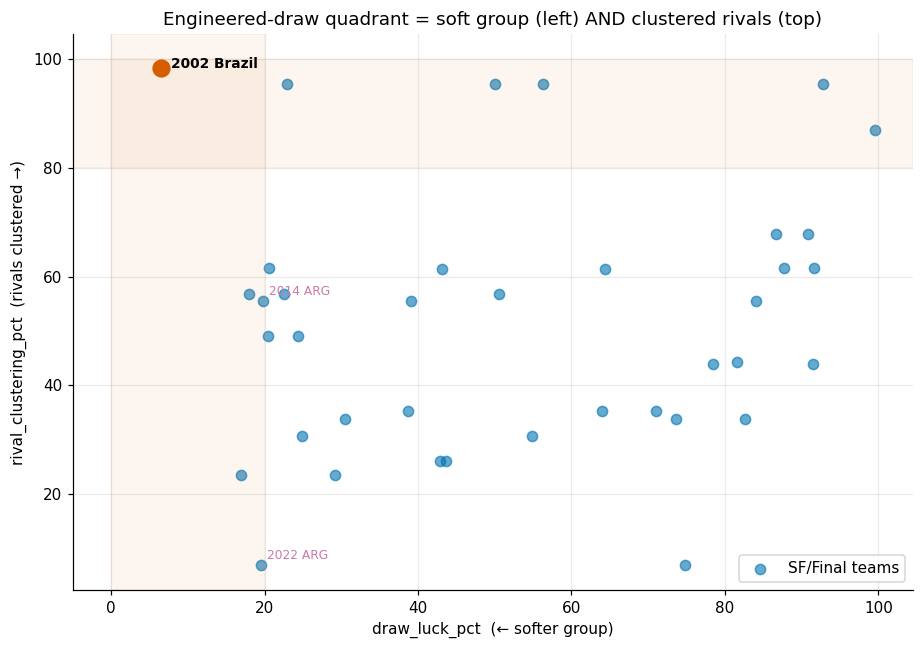

In [23]:
# The engineered signature: soft group AND clustered rivals AND a deep run.
flags = engineered_draw_flags(draws)
print("Teams matching the ENGINEERED-DRAW signature (1954–2022):")
display(flags[["year", "team_name", "round_label",
               "draw_luck_pct", "rival_clustering_pct"]].round(0).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8.5, 6))
deep = draws[draws.round_rank >= 6]
ax.scatter(deep.draw_luck_pct, deep.rival_clustering_pct, s=45, color=PAL[0], alpha=0.6,
           label="SF/Final teams")
for _, r in flags.iterrows():
    ax.scatter(r.draw_luck_pct, r.rival_clustering_pct, s=120, color=PAL[1], zorder=5)
    ax.annotate(f"{int(r.year)} {r.team_name}", (r.draw_luck_pct, r.rival_clustering_pct),
                fontsize=9, fontweight="bold", xytext=(6, 0), textcoords="offset points")
for _, r in deep[deep.team_name == "Argentina"].iterrows():
    ax.annotate(f"{int(r.year)} ARG", (r.draw_luck_pct, r.rival_clustering_pct),
                fontsize=8, color=PAL[3], xytext=(4, 4), textcoords="offset points")
ax.axvspan(0, 20, color=PAL[1], alpha=0.06); ax.axhspan(80, 100, color=PAL[1], alpha=0.06)
ax.set_xlabel("draw_luck_pct  (← softer group)")
ax.set_ylabel("rival_clustering_pct  (rivals clustered →)")
ax.set_title("Engineered-draw quadrant = soft group (left) AND clustered rivals (top)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

**The verdict on draw manipulation.** Exactly **one** team-edition in 1954–2022 lands in the
engineered quadrant — **Brazil 2002**: a group softer than ~93% of fair draws while the other
powers were more clustered than 98% of draws (that was the edition of France, Argentina and
Portugal all going out in the group stage). Even so, this is a *statistical signature, not
evidence of wrongdoing* — someone occupies the tail of any distribution.

And on the original question: **Argentina does not match it.** Their 2014 and 2022 groups were
genuinely soft (softer than ~80% of fair draws — the intuition was right), but the rivals were
**not** clustered — 2022 was in fact the *least*-clustered draw of any edition. In 2002, the one
year rivals *were* clustered, Argentina was the **victim**, drawn into the group of death and
eliminated. So: a lucky soft group, twice — not an engineered path.

### Draw softness by World Cup — the myth-buster table

One row per tournament: how soft the **champion's** group was (rank within its field), how
**balanced vs clustered** the whole draw was, and — the decisive column — *who actually drew the
softest group that year* and whether they won. Use it to sanity-check any "team X had a rigged
easy draw" claim directly.

In [24]:
from worldcup_anomalies.draw import edition_draw_summary

summary = edition_draw_summary(elo, data.group_standings, data.team_appearances, data.tournaments)
display(summary.style.format({
    "champ_group_softness_pct": "{:.0f}", "rival_clustering_pct": "{:.0f}",
}).hide(axis="index"))

won = int(summary.softest_team_won.sum()); n = len(summary)
print(f"MYTH-BUSTER: the team that drew the SOFTEST group won only {won}/{n} editions "
      f"({won/n:.0%}) — both times a host.")
print(f"Champions' group-softness rank ranged from 1st (softest) to "
      f"{int(summary.champ_softness_rank.max())}th of their field — "
      f"2018 France won from a hard group; a soft draw is neither necessary nor sufficient.")
print(f"2022 was the most BALANCED draw on record (rival clustering "
      f"{summary.loc[summary.year==2022,'rival_clustering_pct'].iloc[0]:.0f}%): "
      f"no engineered concentration of rivals.")

year,host,champion,champ_group_softness_pct,champ_softness_rank,n_teams,rival_clustering_pct,softest_group_team,softest_team_won
1954,Switzerland,West Germany,69,5,16,26,England,False
1958,Sweden,Brazil,19,13,16,87,Hungary,False
1962,Chile,Brazil,31,11,16,44,Italy,False
1966,England,England,94,1,16,49,England,True
1970,Mexico,Brazil,12,14,16,95,Soviet Union,False
1974,West Germany,West Germany,56,7,16,35,Italy,False
1978,Argentina,Argentina,31,11,16,31,West Germany,False
1982,Spain,Italy,79,5,24,61,Yugoslavia,False
1986,Mexico,Argentina,79,5,24,44,England,False
1990,Italy,West Germany,96,1,24,23,West Germany,True


MYTH-BUSTER: the team that drew the SOFTEST group won only 2/18 editions (11%) — both times a host.
Champions' group-softness rank ranged from 1st (softest) to 20th of their field — 2018 France won from a hard group; a soft draw is neither necessary nor sufficient.
2022 was the most BALANCED draw on record (rival clustering 7%): no engineered concentration of rivals.


## 11. Detector — FIFA leadership lens (exploratory)

The most speculative view: map each tournament to the FIFA president in office and ask whether
over/under-performance clusters by era. **This is correlational and under-powered** — 22
tournaments across 7 presidents — so treat it as a conversation-starter, not a finding.

The honest result: host over-performance is *higher* in the early decades (when hosting carried a
huge travel/familiarity edge) and *lower* under Blatter/Infantino. The "corruption-era host bias"
hypothesis is **not** supported.

,president,n_tournaments,host_titles,mean_host_overperf,host_reached_final,host_reached_semi
0,Jules Rimet,5,2,2.774277,2,3
1,Arthur Drewry,1,0,3.822844,1,1
2,Stanley Rous,3,1,2.489678,1,2
3,João Havelange,6,2,1.795264,2,3
4,Sepp Blatter,5,1,0.802886,1,3
5,Gianni Infantino,2,0,-0.134041,0,0


Permutation test — host over-performance in the Havelange+Blatter era vs the rest:
  observed difference: -0.92 rounds   p = 0.929
  → no evidence hosts over-performed MORE in that era (if anything, less).


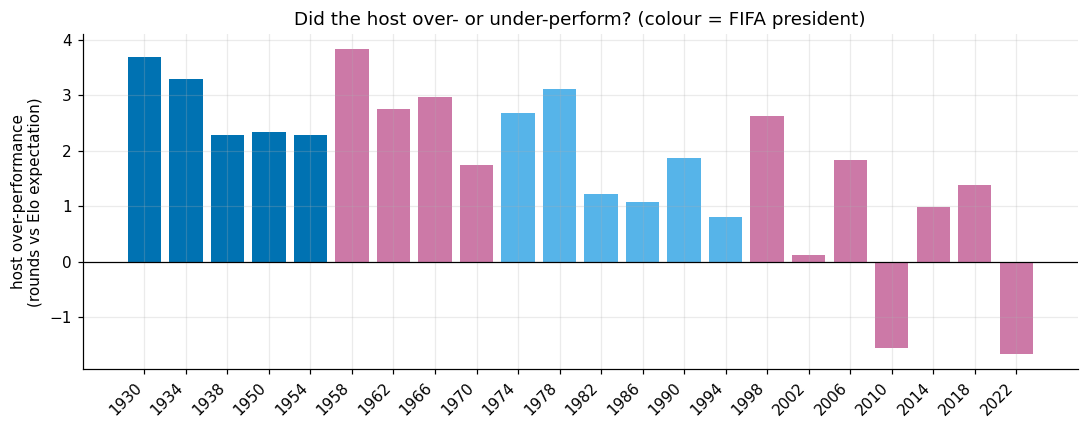

In [25]:
from worldcup_anomalies.leadership import (
    era_summary, host_overperformance, host_overperformance_permutation,
)

es = era_summary(data.tournaments, elo, data.team_appearances, data.leadership)
display(es)

ho = host_overperformance(data.tournaments, elo, data.team_appearances, data.leadership)
perm = host_overperformance_permutation(ho, ["João Havelange", "Sepp Blatter"], n_perm=20000)
print("Permutation test — host over-performance in the Havelange+Blatter era vs the rest:")
print(f"  observed difference: {perm['observed_diff']:+.2f} rounds   p = {perm['p_value']:.3f}")
print("  → no evidence hosts over-performed MORE in that era (if anything, less).")

fig, ax = plt.subplots(figsize=(10, 4))
ho_s = ho.sort_values("year")
colors = [PAL[hash(p) % len(PAL)] for p in ho_s.president]
ax.bar(ho_s.year.astype(str), ho_s.overperformance, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("host over-performance\n(rounds vs Elo expectation)")
ax.set_title("Did the host over- or under-perform? (colour = FIFA president)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 12. Takeaways

- Using ratings grounded in **every international match since 1872** (not just World Cup games)
  removes the cold-start artefact where debutants entered at a neutral 1500 — and it *sharpens*
  the results: the upset list becomes the canonical shocks, and noisy host-performance flags drop
  away.
- The screen **rediscovers known cases**, which is the validation: 1982 Gijón tops the
  convenient-result detector, Cameroon–Brazil 1990 and Saudi Arabia–Argentina 2022 top the upsets,
  and the detector independently rediscovers that the Gijón pattern died with the 1986 simultaneity
  rule.
- The one **systemic signal with a real test behind it** is host card bias: hosts receive fewer
  cards than their opponents ~69% of the time (sign-test p ≈ 0.01, BH q ≈ 0.07). Worth a deeper,
  confounder-aware look — hosts are also often the stronger, more possession-dominant side.
- **Two questions, two different answers, for the same team.** Over the *whole* run Argentina's
  finals were among the *hardest* paths (2022 harder than ~88% of finalist runs) — but that's
  because everyone meets elite teams from the quarter-final on. Isolating the **group draw** (the
  part seeding/the draw controls) flips it: Argentina reached the 2014 and 2022 finals from the
  *softest* and *2nd-softest* seeded groups of their editions. Real pattern, correctly sized: it's
  structural (soft seeded groups are common for eventual champions) and n ≈ 2, so a lead, not a
  verdict. Picking the *right unit of analysis* is the whole game.
- **Lucky ≠ engineered.** A fair-draw Monte-Carlo separates a soft group from an engineered one
  (soft group *and* rivals clustered elsewhere). Only **Brazil 2002** matches the full signature
  in 1954–2022; Argentina's soft 2014/2022 groups do **not** (rivals weren't clustered — 2022 was
  the most balanced draw on record). Even Brazil 2002 is a signature, not proof.
- The **FIFA-leadership lens returns a null**: no era-clustering of host over-performance. Reported
  as-is, because a screen that only ever confirms its priors is worthless.

**Caveats.** Card data starts in 1970. Elo is still a summary of results only (no lineups/xG). Above
all this is a multiple-comparison screen: the q-values quantify how much apparent signal survives.
Treat every row as a lead, not a verdict.